In [1]:
import numpy as np

Mc = lambda k: 1.6114 + 0.037 * k  # (photonic mode approximated as a straight line)
Exca = 1.6229  # (exciton energy)
OM = 3.4 * 1e-3 # (half the Rabi splitting)
hbar_eV_ps = 6.582 * 1e-4 # hbar, converting energy to frequency

def omega_LP(k: float):
    """
    Lower-polariton dispersion in eV and um!

    """

    LP_disp =  0.5 * (Mc(k) + Exca) - 0.5 * ((Mc(k) - Exca)**2 + 4. * OM ** 2) ** 0.5
    return LP_disp


def vg_LP(k: float, dk: float=1e-3):
    return (omega_LP(k + dk/2.) - omega_LP(k - dk/2.)) / dk / hbar_eV_ps


def exciton_fraction(k):
    theta_k = np.arctan(OM / (omega_LP(k) - Mc(k)))
    return np.cos(theta_k) ** 2


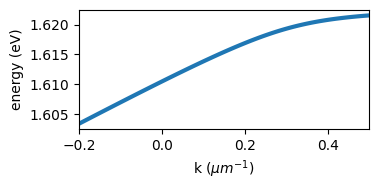

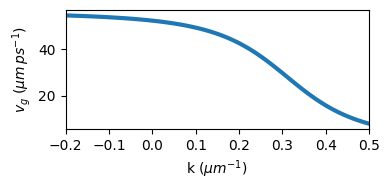

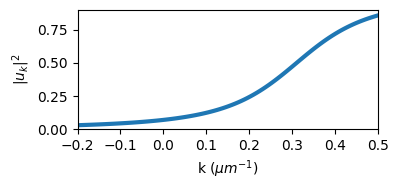

In [10]:
import numpy as np
import matplotlib.pyplot as plt 

k = np.linspace(-.2, .5, 100)
linewidth = 3
figsize = (4,2)
no_title = True
plt.figure(figsize=figsize)
plt.plot(k, omega_LP(k), linewidth=linewidth)
plt.xlabel(r"k ($\mu m^{-1}$)")
plt.ylabel(r"energy (eV)")
if no_title is False:
    plt.title("LP branch")
plt.xlim([np.min(k), np.max(k)])
plt.tight_layout()
plt.show()

plt.figure(figsize=figsize)
plt.plot(k, vg_LP(k), linewidth=linewidth)
plt.xlabel(r"k ($\mu m^{-1}$)")
plt.ylabel(r"$v_g$ ($\mu m\, ps^{-1}$)")
if no_title is False:
    plt.title("group velocity")
plt.xlim([np.min(k), np.max(k)])
plt.tight_layout()
plt.show()

plt.figure(figsize=figsize)
plt.plot(k, exciton_fraction(k), linewidth=linewidth)
plt.xlabel(r"k ($\mu m^{-1}$)")
plt.ylabel(r"$|u_k|^2$")
if no_title is False:
    plt.title("exciton fraction")
plt.xlim([np.min(k), np.max(k)])
plt.ylim(bottom=0.)
plt.tight_layout()
plt.show()

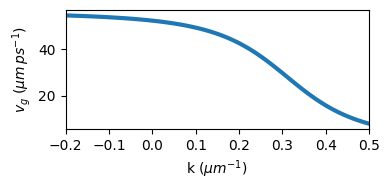

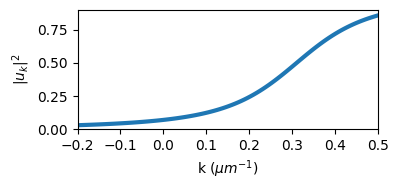

In [11]:
import numpy as np
import matplotlib.pyplot as plt 

k = np.linspace(-.2, .5, 100)
linewidth = 3
figsize = (4,2)
no_title = True

plt.figure(figsize=figsize)
plt.plot(k, vg_LP(k), linewidth=linewidth)
plt.xlabel(r"k ($\mu m^{-1}$)")
plt.ylabel(r"$v_g$ ($\mu m\, ps^{-1}$)")
if no_title is False:
    plt.title("group velocity")
plt.xlim([np.min(k), np.max(k)])
plt.tight_layout()
plt.show()

plt.figure(figsize=figsize)
plt.plot(k, exciton_fraction(k), linewidth=linewidth)
plt.xlabel(r"k ($\mu m^{-1}$)")
plt.ylabel(r"$|u_k|^2$")
if no_title is False:
    plt.title("exciton fraction")
plt.xlim([np.min(k), np.max(k)])
plt.ylim(bottom=0.)
plt.tight_layout()
plt.show()

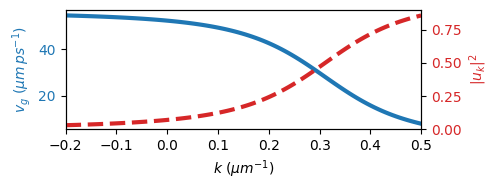

In [13]:
import numpy as np
import matplotlib.pyplot as plt 

k = np.linspace(-.2, .5, 100)
linewidth = 3
figsize = (5, 2)
no_title = True

fig, ax1 = plt.subplots(figsize=figsize)

# Plot 1: Group Velocity (Left Axis, Blue)
color1 = 'tab:blue'
ax1.set_xlabel(r'$k$ ($\mu m^{-1}$)')
ax1.set_ylabel(r'$v_g$ ($\mu m\, ps^{-1}$)', color=color1)
line1 = ax1.plot(k, vg_LP(k), color=color1, linewidth=linewidth)
ax1.tick_params(axis='y', labelcolor=color1)
ax1.set_xlim([np.min(k), np.max(k)])

# Create twin axis for the second plot
ax2 = ax1.twinx()

# Plot 2: Exciton Fraction (Right Axis, Red)
color2 = 'tab:red'
ax2.set_ylabel(r'$|u_k|^2$', color=color2)
line2 = ax2.plot(k, exciton_fraction(k), "--", color=color2, linewidth=linewidth)
ax2.tick_params(axis='y', labelcolor=color2)
ax2.set_ylim(bottom=0.)

# Optional: Combine legends if needed
# lines = line1 + line2
# labels = [l.get_label() for l in lines]
# ax1.legend(lines, labels, loc='upper left')

if not no_title:
    fig.suptitle("Group Velocity and Exciton Fraction")

plt.tight_layout()
plt.show()